In [1]:
import pygetwindow as gw
import pyautogui
from screeninfo import get_monitors
from PIL import Image
import mss
import numpy as np
import cv2

# 查找目標程式的視窗
def capture_window_screenshot(window_title):
    # 查找標題為 window_title 的視窗
    window = gw.getWindowsWithTitle(window_title)

    if len(window) == 0:
        print(f"未找到標題為 '{window_title}' 的視窗")
        return None

    # 取第一個符合標題的視窗
    window = window[0]

    # 取得視窗的位置和大小
    left, top, right, bottom = window.left, window.top, window.right, window.bottom
    print(left, top, right, bottom)
    width = right - left
    height = bottom - top
    print(width, height, width/height)
    # 獲取所有螢幕的資訊
    monitors = get_monitors()
    # 判斷視窗所屬的螢幕
    for monitor in monitors:
        # 判斷視窗是否完全在這個螢幕內
        if left >= monitor.x and right <= monitor.x + monitor.width and bottom >= monitor.y and top <= monitor.y + monitor.height:
            print(f"視窗 '{window_title}' 位於螢幕: {monitor.name}",  monitor.x,  monitor.y,  monitor.width, monitor.height)
            

            with mss.mss() as sct:
                monitor = {"left": left, "top": top, "width": width, "height": height}
                screenshot = sct.grab(monitor)
                np_img = np.array(screenshot)
                np_img = cv2.cvtColor(np_img, cv2.COLOR_BGRA2BGR)
                # 轉換成 PIL Image 以便後續處理或顯示
                img = Image.frombytes("RGB", screenshot.size, screenshot.rgb)
                return img, np_img
            # 根據螢幕的解析度計算需要截取的區域
            # region = (left - monitor.x, top - monitor.y, width, height)
            # screenshot = pyautogui.screenshot(region=region, allScreens=True)
            # # screenshot.show()  # 顯示擷取的畫面
            # return screenshot
            

    print(f"未找到視窗 '{window_title}' 所在的螢幕")
    return None, None



-2379 519 -437 1655
1942 1136 1.7095070422535212
視窗 'MapleStory Worlds-Artale (?????)' 位於螢幕: \\.\DISPLAY5 -3840 0 3840 2160


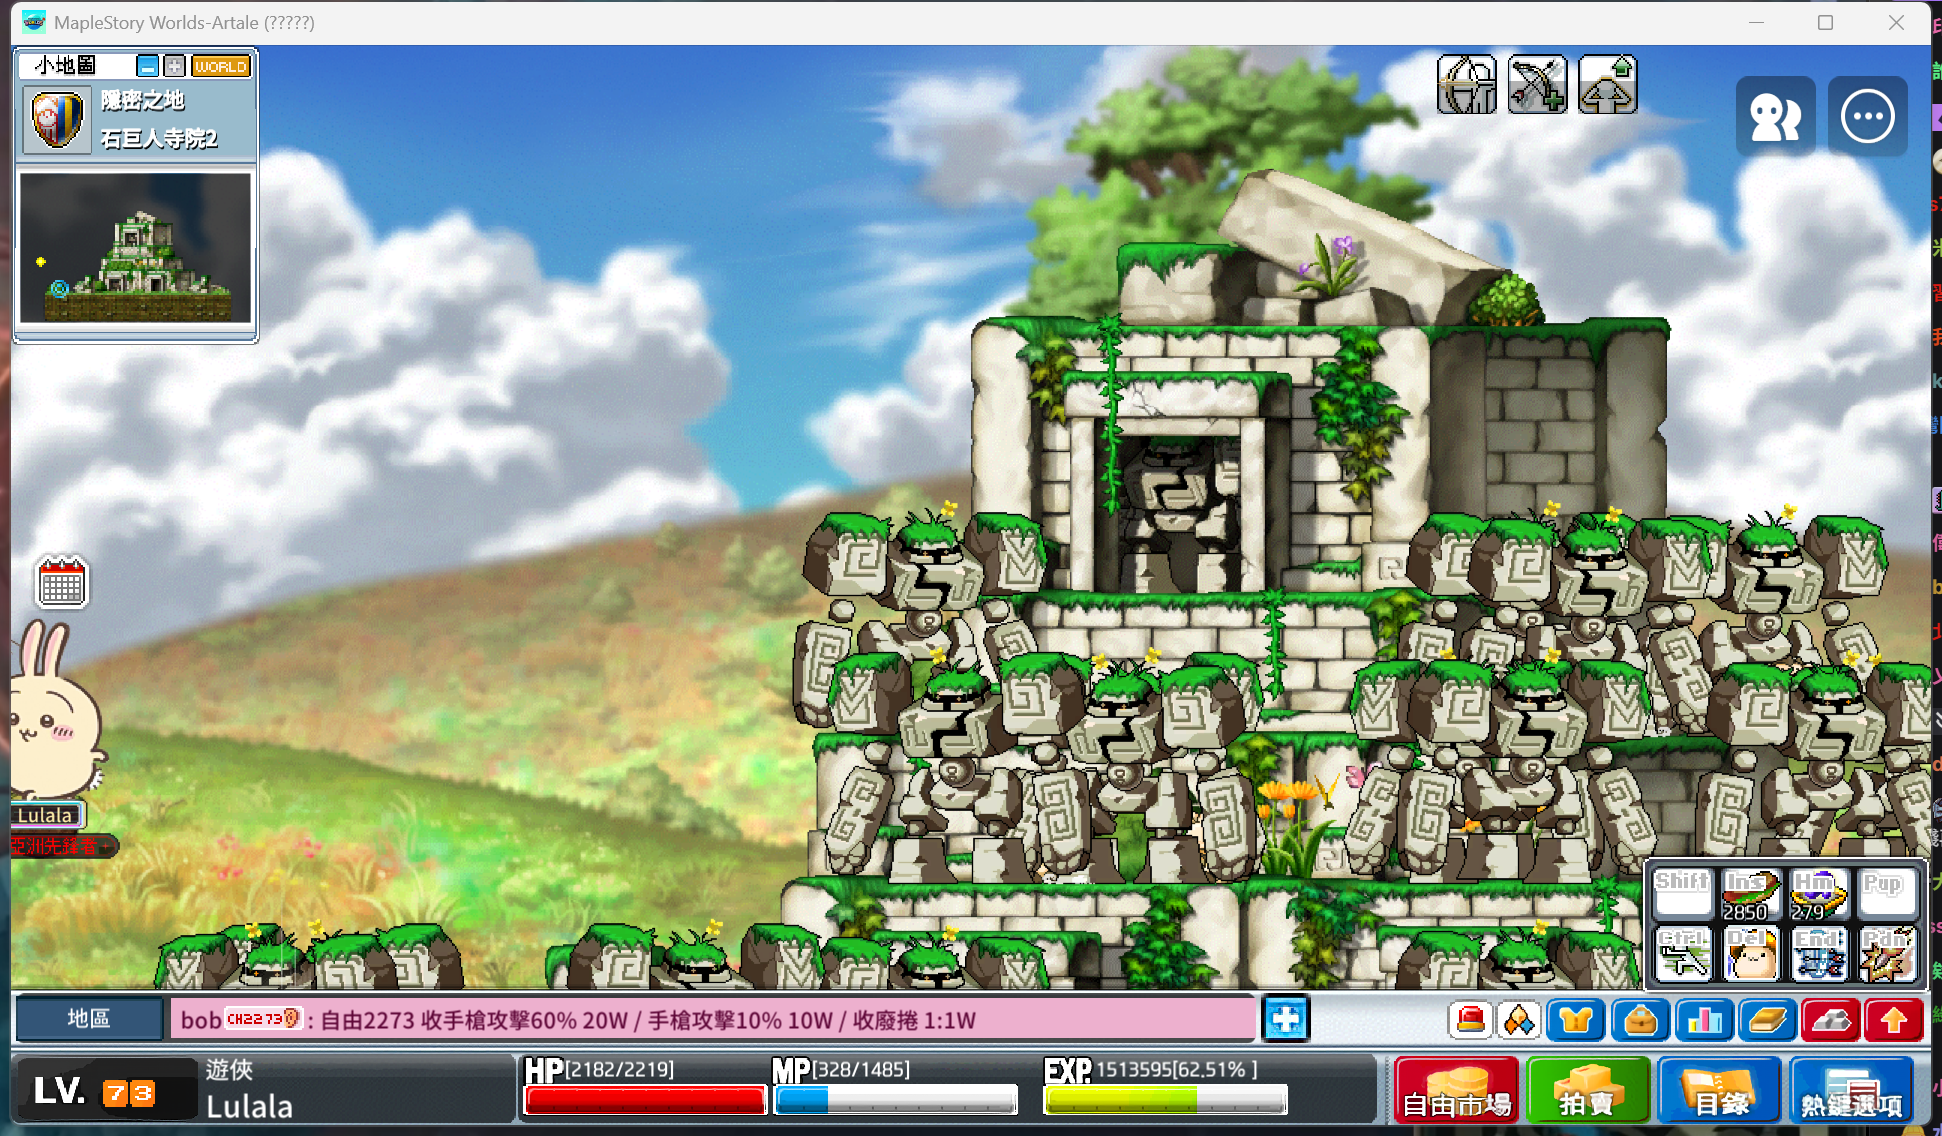

In [2]:
window_title = 'MapleStory Worlds-Artale (?????)' 
img, np_img = capture_window_screenshot(window_title)
img

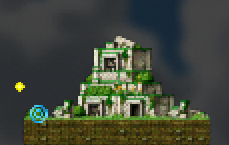

In [3]:
mini_map = img.crop((21, 175, 250, 320))
mini_map

In [7]:
import cv2
import numpy as np
import mss
import os
from glob import glob

# 查找目標程式的視窗
def capture_window_screenshot(window_title):
    # 查找標題為 window_title 的視窗
    window = gw.getWindowsWithTitle(window_title)

    if len(window) == 0:
        print(f"未找到標題為 '{window_title}' 的視窗")
        return None

    # 取第一個符合標題的視窗
    window = window[0]

    # 取得視窗的位置和大小
    left, top, right, bottom = window.left, window.top, window.right, window.bottom
    print(left, top, right, bottom)
    width = right - left
    height = bottom - top
    print(width, height, width/height)
    # 獲取所有螢幕的資訊
    monitors = get_monitors()
    # 判斷視窗所屬的螢幕
    for monitor in monitors:
        # 判斷視窗是否完全在這個螢幕內
        if left >= monitor.x and right <= monitor.x + monitor.width and bottom >= monitor.y and top <= monitor.y + monitor.height:
            print(f"視窗 '{window_title}' 位於螢幕: {monitor.name}",  monitor.x,  monitor.y,  monitor.width, monitor.height)
            

            with mss.mss() as sct:
                monitor = {"left": left, "top": top, "width": width, "height": height}
                screenshot = sct.grab(monitor)
                np_img = np.array(screenshot)
                np_img = cv2.cvtColor(np_img, cv2.COLOR_BGRA2BGR)
                # 轉換成 PIL Image 以便後續處理或顯示
                img = Image.frombytes("RGB", screenshot.size, screenshot.rgb)
                return img, np_img
            # 根據螢幕的解析度計算需要截取的區域
            # region = (left - monitor.x, top - monitor.y, width, height)
            # screenshot = pyautogui.screenshot(region=region, allScreens=True)
            # # screenshot.show()  # 顯示擷取的畫面
            # return screenshot
            

    print(f"未找到視窗 '{window_title}' 所在的螢幕")
    return None, None

def apply_nms(rects, overlapThresh=0.3):
    if len(rects) == 0:
        return []

    boxes = np.array(rects)
    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]

    areas = (x2 - x1) * (y2 - y1)
    order = np.argsort(y2)

    keep = []

    while len(order) > 0:
        i = order[-1]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[:-1]])
        yy1 = np.maximum(y1[i], y1[order[:-1]])
        xx2 = np.minimum(x2[i], x2[order[:-1]])
        yy2 = np.minimum(y2[i], y2[order[:-1]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        inter = w * h
        iou = inter / (areas[i] + areas[order[:-1]] - inter)

        order = order[np.where(iou <= overlapThresh)[0]]

    return boxes[keep].astype(int).tolist()

def detect_monsters(screen, templates_folder='assets/monsters/', threshold=0.3, debug=False):
    all_rects = []

    template_paths = glob(os.path.join(templates_folder, '*.png'))
    scale = 1
    for template_path in template_paths:
        tpl = cv2.imread(template_path, cv2.IMREAD_COLOR)
        templates = [tpl, cv2.flip(tpl, 1)]
        for template in templates:
            h, w = template.shape[:2]
            resized = cv2.resize(template, (int(w * scale), int(h * scale)))
            result = cv2.matchTemplate(screen, resized, cv2.TM_CCOEFF_NORMED)
            loc = np.where(result >= threshold)
            for pt in zip(*loc[::-1]):
                all_rects.append([pt[0], pt[1], pt[0]+w * scale, pt[1]+h * scale])

    final_rects = apply_nms(all_rects)

    if debug:
        debug_img = screen.copy()
        for (x1, y1, x2, y2) in final_rects:
            cv2.rectangle(debug_img, (x1, y1), (x2, y2), (0, 0, 255), 2)
        os.makedirs("debug_output", exist_ok=True)
        output_path = os.path.join("debug_output", "monsters_detected.png")
        cv2.imwrite(output_path, debug_img)
        print(f"偵測結果圖已輸出：{output_path}，偵測到 {len(final_rects)} 隻怪")

    return len(final_rects) > 0
window_title = 'MapleStory Worlds-Artale (?????)' 
img, np_img = capture_window_screenshot(window_title)
res = detect_monsters(np_img, debug=True)
res

-2379 519 -437 1655
1942 1136 1.7095070422535212
視窗 'MapleStory Worlds-Artale (?????)' 位於螢幕: \\.\DISPLAY5 -3840 0 3840 2160
偵測結果圖已輸出：debug_output\monsters_detected.png，偵測到 9 隻怪


True

In [1]:
import cv2
import numpy as np
import mss
import os
from glob import glob
import pygetwindow as gw
from screeninfo import get_monitors
from PIL import Image
import time
import pyautogui
import cv2
import numpy as np
import mss
import os
from glob import glob

# 查找目標程式的視窗
def capture_window_screenshot(window_title):
    # 查找標題為 window_title 的視窗
    window = gw.getWindowsWithTitle(window_title)

    if len(window) == 0:
        print(f"未找到標題為 '{window_title}' 的視窗")
        return None

    # 取第一個符合標題的視窗
    window = window[0]

    # 取得視窗的位置和大小
    left, top, right, bottom = window.left, window.top, window.right, window.bottom
    # print(left, top, right, bottom)
    width = right - left
    height = bottom - top
    # print(width, height, width/height)
    # 獲取所有螢幕的資訊
    monitors = get_monitors()
    # 判斷視窗所屬的螢幕
    for monitor in monitors:
        # 判斷視窗是否完全在這個螢幕內
        if left >= monitor.x and right <= monitor.x + monitor.width and bottom >= monitor.y and top <= monitor.y + monitor.height:
            # print(f"視窗 '{window_title}' 位於螢幕: {monitor.name}",  monitor.x,  monitor.y,  monitor.width, monitor.height)
            

            with mss.mss() as sct:
                monitor = {"left": left, "top": top, "width": width, "height": height}
                screenshot = sct.grab(monitor)
                np_img = np.array(screenshot)
                np_img = cv2.cvtColor(np_img, cv2.COLOR_BGRA2BGR)
                # 轉換成 PIL Image 以便後續處理或顯示
                img = Image.frombytes("RGB", screenshot.size, screenshot.rgb)
                return img, np_img
            # 根據螢幕的解析度計算需要截取的區域
            # region = (left - monitor.x, top - monitor.y, width, height)
            # screenshot = pyautogui.screenshot(region=region, allScreens=True)
            # # screenshot.show()  # 顯示擷取的畫面
            # return screenshot
            

    print(f"未找到視窗 '{window_title}' 所在的螢幕")
    return None, None

def apply_nms(rects, overlapThresh=0.3):
    if len(rects) == 0:
        return []

    boxes = np.array(rects)
    x1 = boxes[:,0]
    y1 = boxes[:,1]
    x2 = boxes[:,2]
    y2 = boxes[:,3]

    areas = (x2 - x1) * (y2 - y1)
    order = np.argsort(y2)

    keep = []

    while len(order) > 0:
        i = order[-1]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[:-1]])
        yy1 = np.maximum(y1[i], y1[order[:-1]])
        xx2 = np.minimum(x2[i], x2[order[:-1]])
        yy2 = np.minimum(y2[i], y2[order[:-1]])

        w = np.maximum(0, xx2 - xx1)
        h = np.maximum(0, yy2 - yy1)

        inter = w * h
        iou = inter / (areas[i] + areas[order[:-1]] - inter)

        order = order[np.where(iou <= overlapThresh)[0]]

    return boxes[keep].astype(int).tolist()
# ... (capture_window_screenshot, apply_nms 函數保持不變) ...

# 偵測小地圖上的角色 (黃色點點) - 改為模板匹配
def detect_character_on_minimap(minimap_img, templates_folder='assets/minimap_character', threshold=0.75, debug=False):
    """
    在小地圖上偵測角色 (黃色點點) 使用模板匹配。
    
    Args:
        minimap_img (np.array): 小地圖的影像 (BGR格式)。
        template_path (str): 角色黃點模板圖片的路徑。
        threshold (float): 模板匹配的相似度閾值。
        debug (bool): 是否儲存偵測結果圖。
        
    Returns:
        list: 角色點的中心座標列表，每個元素為 [center_x, center_y]。
    """

    all_rects = []
    template_paths = glob(os.path.join(templates_folder, '*.png'))
    
    if not template_paths:
        print(f"警告：'{templates_folder}' 資料夾中沒有找到小地圖角色模板模板圖片。")
        return []

    character_centers = []

    for template_path in template_paths:
        dot_template = cv2.imread(template_path, cv2.IMREAD_COLOR)
        if dot_template is None:
            print(f"警告：無法讀取小地圖角色模板圖片：{template_path}")
            continue

        h_tpl, w_tpl = dot_template.shape[:2]
        if dot_template.shape[0] > minimap_img.shape[0] or dot_template.shape[1] > minimap_img.shape[1]:
            return []

        # 使用模板匹配
        result = cv2.matchTemplate(minimap_img, dot_template, cv2.TM_CCOEFF_NORMED)
        loc = np.where(result >= threshold)
        all_dot_rects = []
        for pt in zip(*loc[::-1]):
            all_dot_rects.append([pt[0], pt[1], pt[0] + w_tpl, pt[1] + h_tpl])
        final_dot_rects = apply_nms(all_dot_rects, overlapThresh=0.1)
        for (x1, y1, x2, y2) in final_dot_rects:
            cX = (x1 + x2) // 2
            cY = (y1 + y2) // 2
            character_centers.append([cX, cY])
        if len(character_centers) > 0:
            break

    # if not os.path.exists(template_path):
    #     print(f"錯誤：找不到小地圖角色模板圖片：{template_path}")
    #     return []

    # dot_template = cv2.imread(template_path, cv2.IMREAD_COLOR)
    # if dot_template is None:
    #     print(f"錯誤：無法讀取小地圖角色模板圖片：{template_path}")
    #     return []
    
    # h_tpl, w_tpl = dot_template.shape[:2]
    # if dot_template.shape[0] > minimap_img.shape[0] or dot_template.shape[1] > minimap_img.shape[1]:
    #     return []

    # # 使用模板匹配
    # result = cv2.matchTemplate(minimap_img, dot_template, cv2.TM_CCOEFF_NORMED)
    # loc = np.where(result >= threshold)

    # all_dot_rects = []
    # for pt in zip(*loc[::-1]):
    #     all_dot_rects.append([pt[0], pt[1], pt[0] + w_tpl, pt[1] + h_tpl])


    # final_dot_rects = apply_nms(all_dot_rects, overlapThresh=0.1)

    # character_centers = []
    # for (x1, y1, x2, y2) in final_dot_rects:
    #     cX = (x1 + x2) // 2
    #     cY = (y1 + y2) // 2
    #     character_centers.append([cX, cY])

    if debug:
        debug_img = minimap_img.copy()
        for cX, cY in character_centers:
            # 畫出偵測到的黃點中心，用綠色圓點標示以區分原黃點
            cv2.circle(debug_img, (cX, cY), max(2, w_tpl//2), (0, 255, 0), -1) 
        os.makedirs("debug_output", exist_ok=True)
        output_path = os.path.join("debug_output", "minimap_character_detected.png")
        cv2.imwrite(output_path, debug_img)
        print(f"小地圖角色偵測結果圖已輸出：{output_path}，偵測到 {len(character_centers)} 個黃點，NMS前: {len(all_dot_rects)}")

    return character_centers


# 偵測小地圖上的平台 (棕色/綠色區塊)
def detect_platforms_on_minimap(minimap_img, templates_folder='assets/minimap_platforms/', threshold=0.7, debug=False):
    """
    在小地圖上偵測平台區塊。
    
    Args:
        minimap_img (np.array): 小地圖的影像 (BGR格式)。
        templates_folder (str): 包含小地圖平台模板的資料夾。
        threshold (float): 模板匹配的相似度閾值。
        debug (bool): 是否儲存偵測結果圖。
        
    Returns:
        list: 偵測到的平台 bounding box 列表，每個元素為 [x1, y1, x2, y2]。
    """
    all_rects = []
    template_paths = glob(os.path.join(templates_folder, '*.png'))
    
    if not template_paths:
        print(f"警告：'{templates_folder}' 資料夾中沒有找到小地圖平台模板圖片。")
        return []

    for template_path in template_paths:
        tpl = cv2.imread(template_path, cv2.IMREAD_COLOR)
        if tpl is None:
            print(f"警告：無法讀取小地圖平台模板圖片：{template_path}")
            continue

        h, w = tpl.shape[:2]
        result = cv2.matchTemplate(minimap_img, tpl, cv2.TM_CCOEFF_NORMED)
        loc = np.where(result >= threshold)
        for pt in zip(*loc[::-1]):
            all_rects.append([pt[0], pt[1], pt[0] + w, pt[1] + h])

    final_rects = apply_nms(all_rects, overlapThresh=0.2) # 平台模板可能會有重疊，使用NMS

    if debug:
        debug_img = minimap_img.copy()
        for (x1, y1, x2, y2) in final_rects:
            cv2.rectangle(debug_img, (x1, y1), (x2, y2), (255, 0, 0), 1) # 藍色細框標示平台
        os.makedirs("debug_output", exist_ok=True)
        output_path = os.path.join("debug_output", "minimap_platforms_detected.png")
        cv2.imwrite(output_path, debug_img)
        print(f"小地圖平台偵測結果圖已輸出：{output_path}，偵測到 {len(final_rects)} 個平台區塊")

    return final_rects

# --- 主邏輯部分 ---
def main():
    window_title = "MapleStory Worlds-Artale" 
    
    # 小地圖的固定座標 (需要手動測量)
    # 你可以截取一張遊戲畫面，然後用畫圖工具或其他軟體量測小地圖的左上角和右下角座標
    # 例如：21, 175, 250, 320
    MINIMAP_X_OFFSET = 21 # 根據你的螢幕截圖，小地圖左上角的x座標
    MINIMAP_Y_OFFSET = 175 # 小地圖左上角的y座標
    MINIMAP_WIDTH = 229   # 小地圖的寬度
    MINIMAP_HEIGHT = 145  # 小地圖的高度
    
    # 確保小地圖平台模板資料夾存在且有圖片
    minimap_platform_templates_folder = 'assets/minimap_platforms/'
    if not os.path.exists(minimap_platform_templates_folder) or not glob(os.path.join(minimap_platform_templates_folder, '*.png')):
        print(f"請在 '{minimap_platform_templates_folder}' 資料夾中放置小地圖平台模板圖片！")
        print("程式將終止。")
        return

    # 設定移動參數
    MOVE_THRESHOLD_X_MINIMAP = 10 # 角色中心距離平台邊緣在小地圖上多少像素開始移動
    MOVE_DURATION = 0.15 # 每次移動按鍵按下的時間（秒）
    IDLE_TIME = 0.5 # 每次偵測之間的間隔時間（秒）
    
    # 角色在小地圖Y軸的容忍度 (判斷是否在平台上)
    # 這個值需要根據小地圖的比例和角色黃點與平台邊界的相對位置來調整
    # 建議角色黃點的底部 Y 座標應與平台頂部 Y 座標接近
    MINIMAP_Y_PLATFORM_TOLERANCE = 3 # 角色黃點與平台Y軸的容忍度

    last_move_direction = None # 記錄上次移動方向，避免抖動

    # 設定一個旗標，只在第一次顯示小地圖，讓你確認
    show_minimap_once = False 

    while True:
        pil_img, np_img = capture_window_screenshot(window_title)

        if np_img is None:
            print(f"找不到視窗 '{window_title}'，請確保遊戲正在運行並位於螢幕上。")
            time.sleep(2)
            continue

        # 裁剪小地圖區域
        # 確保裁剪範圍在圖片有效範圍內
        minimap_end_x = MINIMAP_X_OFFSET + MINIMAP_WIDTH
        minimap_end_y = MINIMAP_Y_OFFSET + MINIMAP_HEIGHT

        if minimap_end_x > np_img.shape[1]:
            minimap_end_x = np_img.shape[1]
        if minimap_end_y > np_img.shape[0]:
            minimap_end_y = np_img.shape[0]

        minimap_img = np_img[MINIMAP_Y_OFFSET:minimap_end_y, MINIMAP_X_OFFSET:minimap_end_x]
        
        if minimap_img.size == 0:
            print("裁剪的小地圖區域無效，請檢查座標和尺寸。")
            time.sleep(IDLE_TIME)
            continue
        else:
            # 這是新的部分：顯示裁剪後的小地圖
            if show_minimap_once:
                print(f"裁剪後的小地圖尺寸 (H, W, C): {minimap_img.shape}")
                cv2.imshow("Extracted Minimap (Press 'q' to close)", minimap_img)
                # 等待按鍵，或者等待一段時間自動關閉
                key = cv2.waitKey(0) # 等待任意鍵按下
                if key == ord('q'):
                    cv2.destroyWindow("Extracted Minimap (Press 'q' to close)") # 關閉視窗
                show_minimap_once = False # 只顯示一次


        # 偵測小地圖上的角色位置
        character_centers_minimap = detect_character_on_minimap(minimap_img, debug=True)

        if not character_centers_minimap:
            print("小地圖上未偵測到角色黃點，等待下一次偵測...")
            time.sleep(IDLE_TIME)
            continue

        # 假設只有一個角色，取第一個偵測到的中心點
        char_minimap_center_x, char_minimap_center_y = character_centers_minimap[0]

        # 偵測小地圖上的平台
        platform_rects_minimap = detect_platforms_on_minimap(minimap_img, debug=True)

        # 找到角色當前在小地圖上所處的平台
        current_platform_minimap = None
        for (px1, py1, px2, py2) in platform_rects_minimap:
            # 判斷角色黃點的Y座標是否在平台區域的Y範圍內 (考慮容忍度)
            # 以及X座標是否在平台區域的X範圍內
            if (char_minimap_center_y >= py1 - MINIMAP_Y_PLATFORM_TOLERANCE and 
                char_minimap_center_y <= py2 + MINIMAP_Y_PLATFORM_TOLERANCE and
                char_minimap_center_x >= px1 and 
                char_minimap_center_x <= px2):
                current_platform_minimap = (px1, py1, px2, py2)
                break

        if current_platform_minimap:
            px1, py1, px2, py2 = current_platform_minimap
            
            # 計算角色在平台上的相對位置
            # 如果角色中心太靠近平台左邊緣
            if char_minimap_center_x < px1 + MOVE_THRESHOLD_X_MINIMAP:
                if last_move_direction != 'right':
                    print(f"角色在小地圖上接近平台左邊緣 ({char_minimap_center_x} < {px1 + MOVE_THRESHOLD_X_MINIMAP})，向右移動。")
                    pyautogui.keyDown('right')
                    time.sleep(MOVE_DURATION)
                    pyautogui.keyUp('right')
                    last_move_direction = 'right'
            # 如果角色中心太靠近平台右邊緣
            elif char_minimap_center_x > px2 - MOVE_THRESHOLD_X_MINIMAP:
                if last_move_direction != 'left':
                    print(f"角色在小地圖上接近平台右邊緣 ({char_minimap_center_x} > {px2 - MOVE_THRESHOLD_X_MINIMAP})，向左移動。")
                    pyautogui.keyDown('left')
                    time.sleep(MOVE_DURATION)
                    pyautogui.keyUp('left')
                    last_move_direction = 'left'
            else:
                if last_move_direction is not None:
                    print(f"角色在小地圖上位於平台中央 ({char_minimap_center_x})，停止移動。")
                    # 停止所有方向鍵，避免持續移動
                    pyautogui.keyUp('left')
                    pyautogui.keyUp('right')
                    last_move_direction = None
                else:
                    print(f"角色在小地圖上位於平台中央 ({char_minimap_center_x})，保持靜止。")
        else:
            print("小地圖上未偵測到角色在任何已知的平台上，可能需要跳躍或尋找平台。")
            # 這裡可以添加更複雜的邏輯，例如：
            # - 如果角色Y座標低於所有平台，可能需要按跳躍鍵
            # - 如果角色X座標超出所有平台範圍，可能需要朝最近的平台移動
            # 為了避免角色抖動，可以在此處設置一個跳躍的冷卻時間
            # pyautogui.press('alt') # 假設 alt 是跳躍鍵
            last_move_direction = None # 離開平台狀態，重置移動方向

        time.sleep(IDLE_TIME)

if __name__ == "__main__":
    main()

小地圖角色偵測結果圖已輸出：debug_output\minimap_character_detected.png，偵測到 1 個黃點，NMS前: 1
小地圖平台偵測結果圖已輸出：debug_output\minimap_platforms_detected.png，偵測到 5 個平台區塊
角色在小地圖上位於平台中央 (158)，保持靜止。
小地圖角色偵測結果圖已輸出：debug_output\minimap_character_detected.png，偵測到 1 個黃點，NMS前: 1
小地圖平台偵測結果圖已輸出：debug_output\minimap_platforms_detected.png，偵測到 5 個平台區塊
角色在小地圖上位於平台中央 (158)，保持靜止。
小地圖角色偵測結果圖已輸出：debug_output\minimap_character_detected.png，偵測到 1 個黃點，NMS前: 1
小地圖平台偵測結果圖已輸出：debug_output\minimap_platforms_detected.png，偵測到 5 個平台區塊
角色在小地圖上位於平台中央 (158)，保持靜止。
小地圖角色偵測結果圖已輸出：debug_output\minimap_character_detected.png，偵測到 1 個黃點，NMS前: 1
小地圖平台偵測結果圖已輸出：debug_output\minimap_platforms_detected.png，偵測到 5 個平台區塊
角色在小地圖上位於平台中央 (158)，保持靜止。
小地圖角色偵測結果圖已輸出：debug_output\minimap_character_detected.png，偵測到 1 個黃點，NMS前: 1
小地圖平台偵測結果圖已輸出：debug_output\minimap_platforms_detected.png，偵測到 5 個平台區塊
角色在小地圖上位於平台中央 (158)，保持靜止。
小地圖角色偵測結果圖已輸出：debug_output\minimap_character_detected.png，偵測到 1 個黃點，NMS前: 1
小地圖平台偵測結果圖已輸出：debug_output\minimap_platforms_detected.png，偵測到 5 

KeyboardInterrupt: 

##
偵測角色人物以及平台完成
TODO:
透過平台與角色確保角色保持在平台上
##
